# Notebook 1 - Assess statistical arbitrage signals 

This notebook investigates and evaluates different methods of statistical arbitrage for cryptocurrency assets based on one year of training data.

The goals are: 
1.  Assess opportunities for long-term statistical arbitrage 
    1.  Assess which cryptocurrency pairs may be suitable for pairs trading, and why/why not. 
    2.  Practice utilising different types of statistical modelling techniques to quantify/qualify the existence of pairs trading opportunities. 
2.  Assess opportunities for market microstructure statistical arbitrage. 

Strictly speaking, this analysis counts as part of the **formation period** - we need to bear this analysis phase in mind when doing a proper rollout strategy. 

In [6]:
%load_ext autoreload
%autoreload 2

import lakeapi 
import datetime as dt
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly
import plotly.graph_objects as go 
import numpy as np
from itertools import combinations
import nolds

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from statsmodels.tsa.stattools import coint, adfuller, kpss

#my packages
from test_signal import fit_spread, estimate_half_lives
from scipy.stats import spearmanr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data 

We have downloaded about 9 months worth of level 1 order book data at the 10s frequency. This is because we are interested in investigating long term patterns of pariwise mean reversion - which typically exist at a lower frequency - and shorter term patterns of mean reversion - which might exist at higher frequency levels. 

In [3]:
df = pd.read_parquet("data/level1crypto_raw_origin_times_resampled.parquet")

# InteractiveShell.ast_node_interactivity = "last_expr"
# df.pivot(columns = 'symbol', values = 'ask_0_price').plot(subplots=True, figsize = (20, 40))

As a first pass we look for signals using top level mid price. Note there are other sources which say we should use other price measures - see Vidyamurty. 

In [4]:
#Filter to columns with <5% of missing data 
#
ASSET_COLUMNS = ['BTC-USDT', 
'ETH-USDT', 
'XRP-USDT',
'BNB-USDT', 
'SOL-USDT',      
'TRX-USDT', 
'DOGE-USDT', 
'ADA-USDT',  
'WBTC-USDT',
]
FORMATION_END = '2025-09-01'
prices_df = df.pivot(columns='symbol', values='mid_price').loc[:FORMATION_END][ASSET_COLUMNS]

In [5]:
num_null_by_symbol = prices_df.isna().sum()
num_null_by_symbol/len(prices_df)

symbol
BTC-USDT     0.000007
ETH-USDT     0.002587
XRP-USDT     0.017156
BNB-USDT     0.002791
SOL-USDT     0.017731
TRX-USDT     0.000720
DOGE-USDT    0.017156
ADA-USDT     0.018059
WBTC-USDT    0.041770
dtype: float64

# Signal 1 - Long Term Pairs Trading Opportunities 

## Cointegration 

The most accessible way to test for long term pairs trading signal is assessing whether two price series are cointegrated: that is, if the price series themselves are not stationary - or I(1), but there exists a linear combination of them that IS stationary. The hope then is that this linear combination of two price series - called a portfolio price series - will exhibit mean reversion signals that we can trade on. 

**TESTING METHODOLOGY**

Cointegration is fundamentally about long term mean reversion patterns, so apriori it is not really appropriate to test for long run equilibrium relationships using extremely high frequency data. In this situation we will first try with sampling at 1min frequency.
In effect, this is asking: how strong is the equilibrium relationship at the 1min level? 

**Methodology**:
- Given the small percentage of missing data, we just front fill for testing purposes. 
- To give a fuller picture we use both the ADF and KPSS tests for stationarity. The null hypothesis of the ADF test is that there IS a unit root (i.e non-stationary) whilst the null hypothesis of the KPSS test is that teh time series is stationary. 

In [ ]:
# Which price series exhibit non-stationarity i.e. I(1) behaviour? 
subsampled_df = prices_df.asfreq('1min').ffill()

for col in subsampled_df: 
    print(f"Statistical tests for {col}, subsampled to 1 minute")
    price_series = subsampled_df[col]
    print(f"ADF: {adfuller(price_series)[1]}")
    print(f"KPSS: {kpss(price_series)}")

for col in subsampled_df: 
    print(f"Statistical tests for first difference {col}, subsampled to 1 minute")
    first_difference = subsampled_df[col].diff()[1:]
    print(f"ADF: {adfuller(first_difference)[1]}")
    print(f"KPSS: {kpss(first_difference)}")

All coins qualify as unit root price series. 

In [ ]:
# Cointegration - Test 

UNIT_ROOT = [
    'ADA-USDT', 
    'BTC-USDT', 
    'SOL-USDT', 
    'TRX-USDT', 
    'DOGE-USDT', 
    'ADA-USDT',
    'WBTC-USDT'
]

from itertools import combinations
for (x, y) in combinations(UNIT_ROOT, 2): 
    print(f"Cointegration test for x = {x}, y = {y}")
    x_price = prices_df[x].asfreq('1min').ffill()
    y_price = prices_df[y].asfreq('1min').ffill()
    #chop to adjust the two price series
    common_len = min(len(x_price), len(y_price))  
    coint(x_price[:common_len], y_price[:common_len])
    #also do the reverse way 
    print(f"Cointegration test for x = {y}, y = {x}")
    coint(y_price[:common_len], x_price[:common_len])

## Hurst Exponents 

The cointegration approach gives a statistically robust way to detect mean reversion but it is not perfect, for two reasons: 
1. Stationarity of a portfolio price series does not indicate anything about the SPEED of possible mean reversion. 
2. Second, in general the concept of price series stationarity does not directly IMPLY mean reversion. It is only relevant when we are modelling AR(p) procesesses. 

It is much more desirable to directly quantify the speed of mean reversion of any given candidate price spread. We use the Generalised Hurst Exponent. 

**Generalised Hurst Exponent**

Let us assume and fit the following **long term** relationship: 

\begin{equation}
K_{q}(\tau) := \frac{\langle |X_{t+\tau} - X_t|^q \rangle}{\langle |X_t|^q \rangle} \propto \tau^{qH(q)} \quad \text{as } \tau \to \infty
\end{equation}

For q = 1, it is known that a geometric random walk exhibits Hurst exponent = 0.5. For a mean reverting series, H < 0.5 and for a trending series, H > 0.5.

**How we use the Hurst Exponent**

It is important to note that the GEH is not strictly speaking a test statistic. It is estimated by log-log linear regression. 

For a first pass, we follow the approach utilised by Requena et al (2021) that estimates the Hurst exponent of the logged price ratio between two assets.

We will also estimate the Hurst Exponent for the estimated spread series that we derived from the cointegration analysis above. 

In [35]:
## Estimation - Hurst Exponents - Logged Prices 

log_prices_df = np.log(prices_df.asfreq('1min').ffill())
log_spread_df= pd.DataFrame({f'log({p1}/{p2})': (log_prices_df[p1]-log_prices_df[p2]) for (p1,p2) in combinations(log_prices_df.columns, 2)})
hurst_df = pd.DataFrame({
    col: nolds.mfhurst_b(log_spread_df[col], qvals=[1, 2, 3, 4]) 
    for col in log_spread_df
}, index=['q=1', 'q=2', 'q=3', 'q=4']).T

hurst_df.sort_values(['q=1', 'q=2', 'q=3', 'q=4']).head(n=10)

,q=1,q=2,q=3,q=4
log(BTC-USDT/WBTC-USDT),0.206122,0.201044,0.164287,0.126671
log(DOGE-USDT/ADA-USDT),0.481411,0.481092,0.444168,0.392174
log(SOL-USDT/ADA-USDT),0.494915,0.492912,0.464656,0.417734
log(ETH-USDT/ADA-USDT),0.495442,0.485309,0.434067,0.375254
log(SOL-USDT/DOGE-USDT),0.495750,0.481854,0.455133,0.418088
log(BTC-USDT/ADA-USDT),0.497609,0.487978,0.445349,0.386727
log(ETH-USDT/DOGE-USDT),0.497650,0.465668,0.391653,0.302477
log(ADA-USDT/WBTC-USDT),0.498266,0.488407,0.445573,0.386887
log(XRP-USDT/ADA-USDT),0.501077,0.493577,0.460812,0.411673
log(TRX-USDT/ADA-USDT),0.501356,0.499446,0.467713,0.418427


None of the estimated Hurst Exponent estimates differ significantly from 0.5, apart from BTC/WBTC since they are functionally the same coin. Note the results are similar regardless of whether we form a candidate portfolio via log-log spreads or via ADA/DOGE. 

In [36]:
PAIRS = [
    ('BTC-USDT', 'TRX-USDT'),
    ('TRX-USDT', 'BTC-USDT'), 
    ('ADA-USDT', 'SOL-USDT'), 
    ('TRX-USDT', 'WBTC-USDT'), 
    ('WBTC-USDT', 'TRX-USDT'),
    ('DOGE-USDT', 'ADA-USDT'), 
    ('ADA-USDT', 'DOGE-USDT')
]

cointegrated_spreads_df = pd.DataFrame({
    f"{pair}": fit_spread(x = subsampled_df[pair[0]], y = subsampled_df[pair[1]])for pair in PAIRS
})

hurst_cointegrated_df = pd.DataFrame({
    col: nolds.mfhurst_b(cointegrated_spreads_df[col], qvals=[1, 2, 3, 4]) 
    for col in cointegrated_spreads_df
}, index=['q=1', 'q=2', 'q=3', 'q=4']).T
hurst_cointegrated_df.sort_values(['q=1', 'q=2', 'q=3', 'q=4'])

,q=1,q=2,q=3,q=4
"('ADA-USDT', 'DOGE-USDT')",0.475816,0.468137,0.425959,0.378247
"('DOGE-USDT', 'ADA-USDT')",0.481258,0.470644,0.422185,0.368973
"('ADA-USDT', 'SOL-USDT')",0.498545,0.480332,0.406748,0.327312
"('TRX-USDT', 'WBTC-USDT')",0.510790,0.503740,0.474485,0.434528
"('TRX-USDT', 'BTC-USDT')",0.512328,0.502174,0.471333,0.431899
"('WBTC-USDT', 'TRX-USDT')",0.518602,0.518230,0.485383,0.446245
"('BTC-USDT', 'TRX-USDT')",0.519510,0.517179,0.484118,0.445455


## Half-Life Estimation 

Another empirical method used for assessing the *degree* of mean reversion is to try and model the "time" it takes for a portfolio price series to mean revert. 

- We can do this directly by measuring "time between zero crossings", but this is rather ill-defined especially for higher frequency data, since we have to define a "threshold" for how significant a crossing has to be before we count it as a zero crossing. 

Therefore, I adopt the parametric method of estimating the half-life. This is based on modelling a candidate price series as an AR(1) model. 

## Half-Life of Mean Reversion

The half-life of mean reversion is the expected time for a spread to revert 
halfway back to its mean following a deviation.

### Setup

Consider a weakly stationary AR(1) process:

$$X_t = c + \phi_1 X_{t-1} + \epsilon_t, \quad |\phi_1| < 1$$

Taking expectations of both sides and using $\mathbb{E}[X_t] = \mu$:

$$\mu = \frac{c}{1 - \phi_1}$$

Rewriting in terms of deviations from the mean $Y_t = X_t - \mu$:

$$Y_t = \phi_1 Y_{t-1} + \epsilon_t$$

### Half-Life Derivation

We seek $h$ such that the expected deviation halves:

$$\mathbb{E}_t[Y_{t+h}] = \frac{1}{2} Y_t$$

Since $\mathbb{E}_t[Y_{t+h}] = \phi_1^h Y_t$, this gives:

$$\phi_1^h Y_t = \frac{1}{2} Y_t \implies h = \frac{-\ln(2)}{\ln(|\phi_1|)}$$

### Connection to OLS Estimation

In practice we estimate $\phi_1$ by fitting:

$$\Delta S_t = \beta S_{t-1} + \epsilon_t$$

where $\beta = \phi_1 - 1$, giving the equivalent expression:

$$\text{half-life} = \frac{-\ln(2)}{\ln(|1 + \beta|)} \approx \frac{-\ln(2)}{\beta}$$

where the approximation holds for small $\beta$ (slow mean reversion).

For pairs trading, the half-life determines practical tradability:
- Too short → cannot execute trades fast enough
- Too long → capital tied up, insufficient trading frequency
- Sweet spot → half-life consistent with execution horizon

In [38]:
from itertools import permutations

all_pairs = list(permutations(subsampled_df.columns, 2))
estimate_half_lives(pairs=all_pairs, prices_df=subsampled_df).head(n=10)

,pair,beta,phi1,p_value,mean_reverting,half_life_bars,half_life_mins
31,WBTC-USDT/BTC-USDT,-0.001406,0.998594,0.0000,True,492.8,492.8
10,BTC-USDT/WBTC-USDT,-0.001405,0.998595,0.0000,True,492.9,492.9
12,DOGE-USDT/ADA-USDT,-0.000067,0.999933,0.0000,True,10332.9,10332.9
1,ADA-USDT/DOGE-USDT,-0.000059,0.999941,0.0000,True,11834.9,11834.9
35,WBTC-USDT/XRP-USDT,-0.000055,0.999945,0.0000,True,12578.9,12578.9
11,BTC-USDT/XRP-USDT,-0.000055,0.999945,0.0000,True,12612.2,12612.2
29,TRX-USDT/XRP-USDT,-0.000054,0.999946,0.0001,True,12799.2,12799.2
23,SOL-USDT/XRP-USDT,-0.000054,0.999946,0.0000,True,12895.5,12895.5
34,WBTC-USDT/TRX-USDT,-0.000045,0.999955,0.0003,True,15378.8,15378.8
28,TRX-USDT/WBTC-USDT,-0.000045,0.999955,0.0005,True,15493.9,15493.9


Note that p-values here need a degree of freedom correction since we estimated the spread first before fitting an AR(1). The most important thing to note is: 
- phi estimates suggest something close to a random walk. 
- Very long half-life estimates, all of them longer than a week. 

This accords with our visual intuition. 

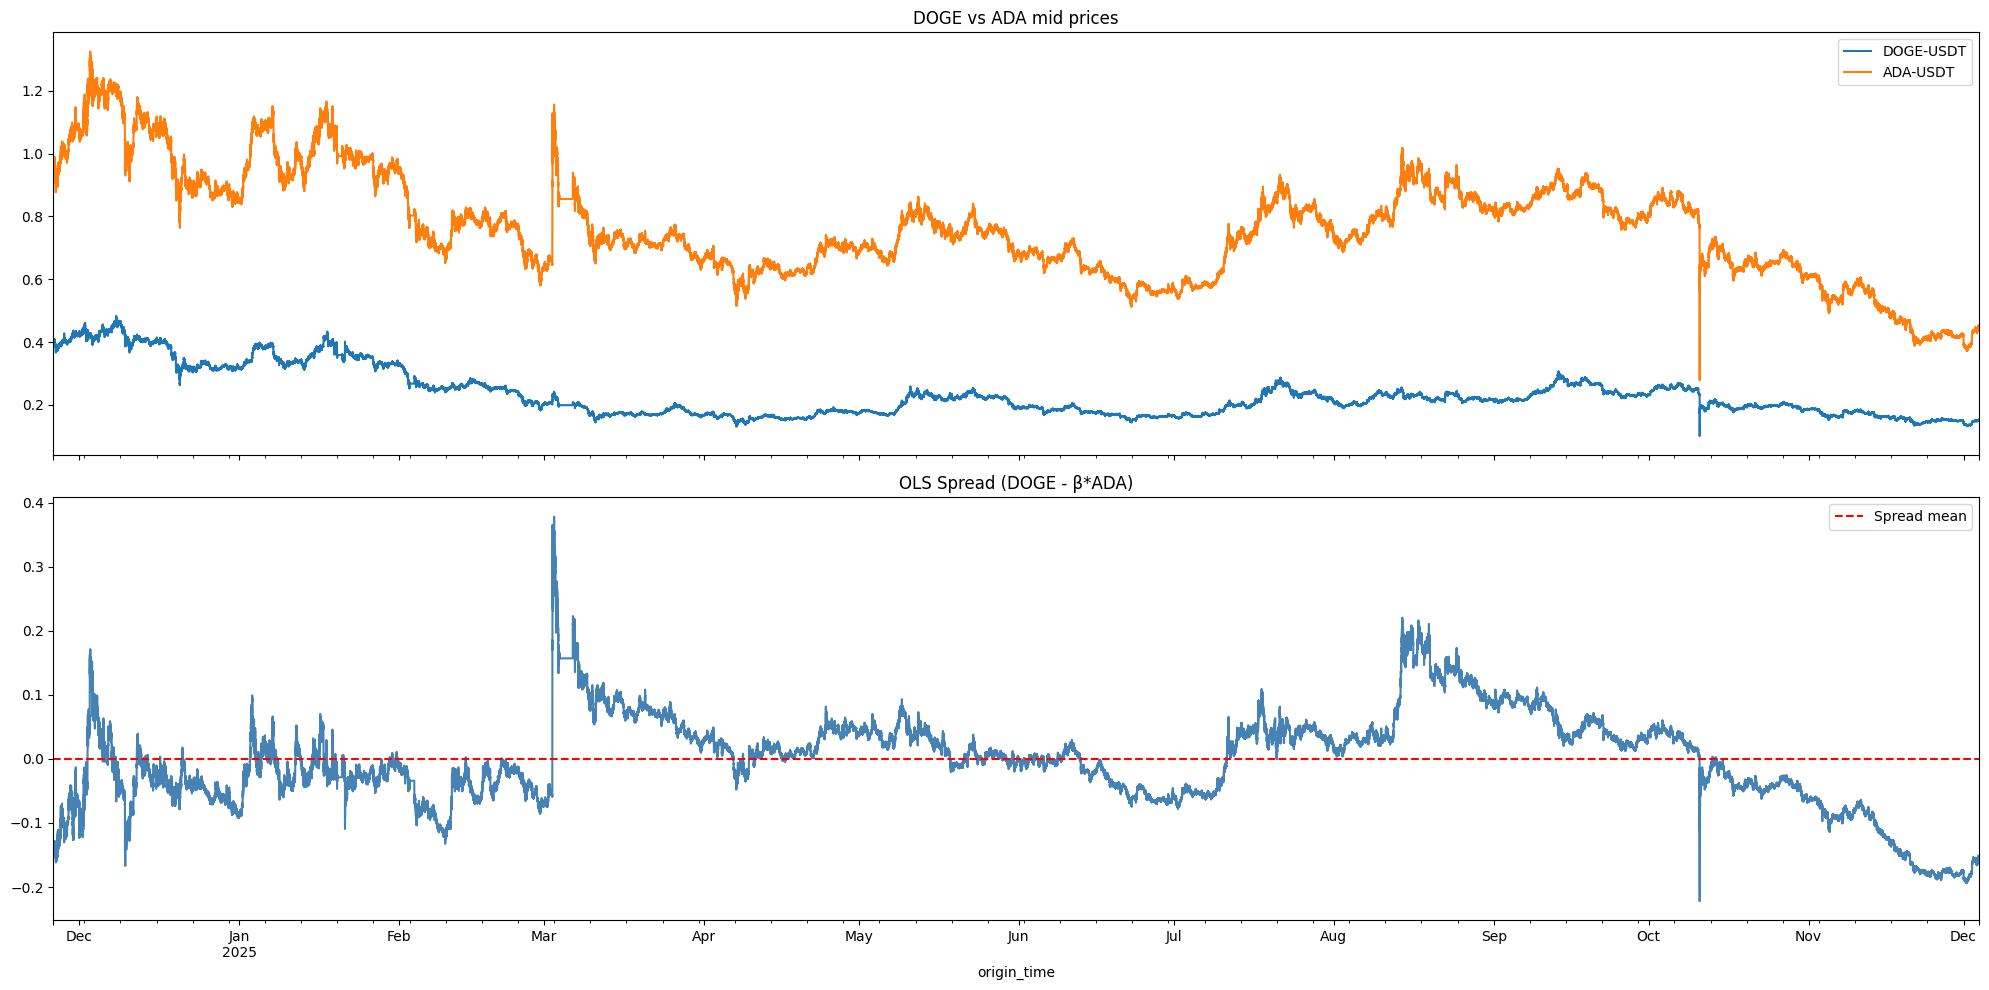

In [17]:
InteractiveShell.ast_node_interactivity = "last_expr"
spread = fit_spread(x=subsampled_df['DOGE-USDT'], y=subsampled_df['ADA-USDT'])

fig, axes = plt.subplots(nrows=2, figsize=(20, 10), sharex=True)

# top: price series
subsampled_df[['DOGE-USDT', 'ADA-USDT']].plot(ax=axes[0], title='DOGE vs ADA mid prices')
axes[0].legend()

# bottom: spread
spread.plot(ax=axes[1], color='steelblue', title='OLS Spread (DOGE - β*ADA)')
axes[1].axhline(y=spread.mean(), linestyle='--', color='red', label='Spread mean')
axes[1].legend()

plt.tight_layout()
plt.show()

# Does the data frequency count? 

So far our analysis has focused on the analysis of **long term** pairs trading signals.

I have started with 1min frequency data to initially maximise power of statistical tests, but it is not clear what trading frequency is appropriate when assessing long term pairs trading opportunities. 

A very naive half life/hurst exponent suggests we might have better luck with INTERDAY rather than intraday trading. 

This is most likely due to the fact that we have netted out the relevant effects of microstructure noise. 

In [39]:
# Does the data frequency count? 

estimate_half_lives(pairs = all_pairs, prices_df = prices_df.asfreq('1D').ffill()).head(n=10)

,pair,beta,phi1,p_value,mean_reverting,half_life_bars,half_life_mins
31,WBTC-USDT/BTC-USDT,-0.887895,0.112105,0.0000,True,0.3,456.1
10,BTC-USDT/WBTC-USDT,-0.887739,0.112261,0.0000,True,0.3,456.4
34,WBTC-USDT/TRX-USDT,-0.178091,0.821909,0.0000,True,3.5,5089.2
9,BTC-USDT/TRX-USDT,-0.174128,0.825872,0.0000,True,3.6,5217.2
12,DOGE-USDT/ADA-USDT,-0.131645,0.868355,0.0000,True,4.9,7071.2
28,TRX-USDT/WBTC-USDT,-0.118009,0.881991,0.0000,True,5.5,7948.6
25,TRX-USDT/BTC-USDT,-0.114297,0.885703,0.0001,True,5.7,8223.7
40,XRP-USDT/TRX-USDT,-0.110053,0.889947,0.0001,True,5.9,8560.8
1,ADA-USDT/DOGE-USDT,-0.103964,0.896036,0.0001,True,6.3,9092.6
29,TRX-USDT/XRP-USDT,-0.086307,0.913693,0.0003,True,7.7,11058.3


In [40]:
log_prices_df = np.log(prices_df.asfreq('1D').ffill())
log_spread_df= pd.DataFrame({f'log({p1}/{p2})': (log_prices_df[p1]-log_prices_df[p2]) for (p1,p2) in combinations(log_prices_df.columns, 2)})
hurst_df = pd.DataFrame({
    col: nolds.mfhurst_b(log_spread_df[col], qvals=[1, 2, 3, 4]) 
    for col in log_spread_df
}, index=['q=1', 'q=2', 'q=3', 'q=4']).T

hurst_df.sort_values(['q=1', 'q=2', 'q=3', 'q=4']).head(n=10)

,q=1,q=2,q=3,q=4
log(BTC-USDT/WBTC-USDT),0.083772,0.026786,0.020637,0.019101
log(BNB-USDT/TRX-USDT),0.391656,0.233726,0.083132,0.010653
log(TRX-USDT/WBTC-USDT),0.404210,0.223770,0.070393,0.003384
log(BTC-USDT/TRX-USDT),0.411053,0.228299,0.073112,0.005655
log(XRP-USDT/TRX-USDT),0.417217,0.286205,0.126392,0.019516
log(SOL-USDT/TRX-USDT),0.443514,0.329522,0.182981,0.082025
log(DOGE-USDT/ADA-USDT),0.444000,0.390076,0.290298,0.216257
log(XRP-USDT/BNB-USDT),0.455395,0.410481,0.354858,0.312442
log(XRP-USDT/WBTC-USDT),0.473218,0.431234,0.397086,0.376616
log(TRX-USDT/ADA-USDT),0.473566,0.302856,0.134716,0.033175


# Are these cointegrating relationships stable? Are they likely to persist into time? 

The ultimate test of a trading strategy is whether the "edge" we have found 
will persist into the future.

Even a statistically significant cointegration test is no guarantee that a 
relationship will persist out of sample. What gives us confidence is the 
combination of statistical evidence AND an economic mechanism that enforces 
the relationship.

For example, BTC-USDT and WBTC-USDT comove because they represent the same 
underlying asset — any divergence is a direct arbitrage opportunity that 
market participants will close immediately. This economic mechanism means 
cointegration, when found, is likely to persist.

For other coin pairs however, the picture is much less clear:

- **No economic mechanism**: Most crypto pairs have no fundamental relationship 
  that forces prices back together after divergence. Without a mechanism, 
  statistical cointegration is potentially spurious.

- **Frequency instability**: Hurst exponent rankings are inconsistent across 
  sampling frequencies — genuine structural relationships should appear 
  robustly regardless of how you sample the data.

- **Data mining risk**: Sole reliance on hypothesis tests across many pairs 
  raises concerns about p-value hacking — with enough pairs tested, spurious 
  rejections are inevitable.

For these reasons, we do not pursue pairs trading beyond the immediately obvious BTC/WBTC without further economic justification.

## Signal 1: Lead Lag Correlation 

In [22]:
# Lead-Lag Correlation 
# Do BTC returns predict other asset returns at lag k?
returns_df = prices_df.pct_change()
results = {}
for lag in [1, 2, 3, 6, 12]:
    lagged_btc = returns_df['BTC-USDT'].shift(lag) #LAG THE RETURNS BACKWARDS IN TIME 
    results[lag] = returns_df.corrwith(lagged_btc, method='spearman')

pd.DataFrame(results).round(3)

/var/folders/ym/_trdyjp50zv02lvg3nv9km7h0000gn/T/ipykernel_55431/2308424317.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = prices_df.pct_change()


,1,2,3,6,12
symbol,,,,,
BTC-USDT,0.106,0.027,0.015,0.005,0.005
ETH-USDT,0.028,0.001,0.000,-0.001,0.001
XRP-USDT,0.033,0.004,0.004,0.003,0.003
BNB-USDT,0.100,0.017,0.007,0.002,0.004
SOL-USDT,0.056,0.006,0.003,0.002,0.003
TRX-USDT,0.080,0.024,0.012,0.003,0.003
DOGE-USDT,0.036,0.005,0.003,0.003,0.003
ADA-USDT,0.052,0.005,0.004,0.003,0.004
WBTC-USDT,0.038,0.012,0.008,0.003,0.004


There is a very weak correlation between lagged BTC returns and other coin returns at the 10s level. 

## Conclusions 

## Long Term Cointegration 

Cointegration and Hurst exponent estimates were computed at both 10 second 
and daily frequency. Two observations:

1. **Weak signal at both frequencies**: Neither frequency produces Hurst 
   exponents meaningfully below 0.5, suggesting most pairs are close to 
   random walks regardless of sampling frequency.

2. **Rankings are unstable across frequencies**: Pairs that appear most 
   mean-reverting at 10 second frequency are not the same pairs that appear 
   most mean-reverting at daily frequency.

This instability is the key finding. A genuine structural mean-reverting 
relationship should appear robustly regardless of how you sample the data — 
the same pairs should rank consistently at both frequencies. The fact that 
rankings change suggests we are measuring noise rather than a persistent 
structural signal.

The exception is BTC/WBTC which ranks consistently at both frequencies — 
consistent with a genuine economic relationship rather than a statistical 
artefact.

## Short Term - Microstructure Signals 
Simple microstructure signals like lead-lag correlation are not present at 10s data. 